
# <font color= #003366> **Image-to-Sketch Translation using Conditional GANs (Pix2Pix)** </font>
- <Strong> Subject: </Strong>  <font color="blue">`Deep Learning` </font>
- <Strong> Project 2: </Strong>  <font color="blue">`GANs` </font>

<div style="display: flex; align-items: center;">
    <div style="flex: 1;">
        <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="300">
    </div>
</div>

___

## <font color=  #003366> **Introducción**</font>

En esta sección se implementa la GAN para convertir imágenes de gatos en sketches

Se utiliza una arquitectura del tipo image-to-image translation, inspirada en Pix2Pix, donde el modelo aprende una entre la entrada que es la foto del gato y su respectiva salida que es el sketch.

El modelo está compuesto por dos redes principales:

Generador: encargado de transformar la imagen real en un sketch.
Discriminador: encargado de distinguir entre sketches reales y generados.

El entrenamiento se basa en una función de pérdida combinada que incluye:

- Una pérdida (GAN), que trata de generar imágenes realistas
- Una pérdida de reconstrucción (L1), que asegura que la salida conserve la estructura de la imagen original.

El dataset utilizado está estructurado en pares alineados de imágenes (fotografía | sketch), lo que permite al modelo aprender la transformación deseada.

Finalmente, se evalúa el desempeño del modelo tanto de forma visual así como mediante métricas como FID, analizando también la robustez del modelo ante ruido en las imágenes de entrada.

---

En este caso al hacer la prueba del modelo, las imágenes del test a diferencia del primer experimento donde eran A|A, son A|B para poder hacer la comparación entre los sketches reales y los fakes

## <font color=  #003366> **Clonación de Repo**</font>

In [1]:
!git clone https://github.com/Moni-Ib/Project2_GANs.git
%cd Project2_GANs

Cloning into 'Project2_GANs'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 69 (delta 14), reused 67 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 40.44 KiB | 8.09 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/Project2_GANs


## <font color=  #003366> **Librerías**</font>

In [3]:
!pip install pytorch-fid

In [4]:
import re
import matplotlib.pyplot as plt
import os
from PIL import Image
import shutil
import cv2
import numpy as np
import shutil
from pytorch_fid import fid_score
import torch
import sys
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import shutil
from pytorch_fid import fid_score
import torchvision.transforms as T
import torch.nn as nn
from torchvision.models import resnet18


## <font color=  #003366> **Conectar con Drive**</font>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!cp -r /content/drive/MyDrive/dataset/cats_final ./dataset

In [7]:
import torch
torch.cuda.is_available()

True

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## <font color=  #003366> **Requirements**</font>

In [ ]:
!pip install torch torchvision opencv-python

## <font color=  #003366> **Entrenamiento del modelo**</font>

In [10]:
!pip install dominate

In [33]:
!export PYTHONPATH=$PYTHONPATH:/content/Project2_GANs/src/models/apdrawing_gan && \
python src/models/apdrawing_gan/train.py \
--dataroot /content/Project2_GANs/dataset \
--name cats_pix2pix \
--model apdrawing_gan \
--netG unet_256 \
--dataset_mode aligned \
--which_direction AtoB \
--display_id -1 \
--batch_size 4 \
--niter 15 \
--niter_decay 5 \
--fineSize 256 \
--loadSize 256 \
--gpu_ids 0 \
--lambda_L1 25 \
--num_threads 2

----------------- Options ---------------
                    EYE_H: 40                            
                    EYE_W: 56                            
                  MOUTH_H: 40                            
                  MOUTH_W: 64                            
                   NOSE_H: 48                            
                   NOSE_W: 48                            
                  addw_bg: 1.0                           
                 addw_eye: 1.0                           
                addw_hair: 1.0                           
               addw_mouth: 1.0                           
                addw_nose: 1.0                           
           auxiliary_root: auxiliary                     
               batch_size: 4                             	[default: 1]
                    beta1: 0.5                           
                   bg_dir: dataset/mask/ALL              
          checkpoints_dir: ./checkpoints                 
                 

Para entrenar el modelo se usó la misma arquitectura pasada la cual está basada en Pix2Pix, que sirve para convertir una imagen en otra, en este caso de una foto de gato a un sketch.

El generador es una red tipo U-Net (unet_256), que es importante porque tiene una estructura que conecta las capas iniciales con las finales, lo que ayuda a no perder detalles importantes de la imagen original. Gracias a esto, el modelo puede mantener bien la forma y características del gato en el sketch generado.

Por otro lado, el discriminador se encarga de evaluar si los sketches son reales o generados, lo que hace que el generador tenga que ir mejorando conforme avanza el entrenamiento.

En cuanto a los hiperparámetros, se entrenó el modelo con imágenes de 256×256, usando un batch size de 4, lo cual ayuda a que el entrenamiento sea más estable aunque tarde un poco más.

También se utilizó 15 épocas iniciales y 5 de ajuste un poco más fino, donde en la segunda parte el modelo va ajustando más fino sus pesos.

La función de pérdida combina dos partes: una pérdida GAN, que hace que las imágenes se vean más realistas, y una pérdida L1, que le da bastante peso a que el sketch se parezca a la imagen original en estructura.

En este caso se usó un valor de lambda_L1 = 25, lo que hace que el modelo priorice bastante la similitud con la imagen real. En conjunto, estos parámetros permiten que el modelo aprenda de forma estable y genere sketches coherentes a partir de las fotos.

## <font color=  #003366> **Visualización de Pérdidas**</font>

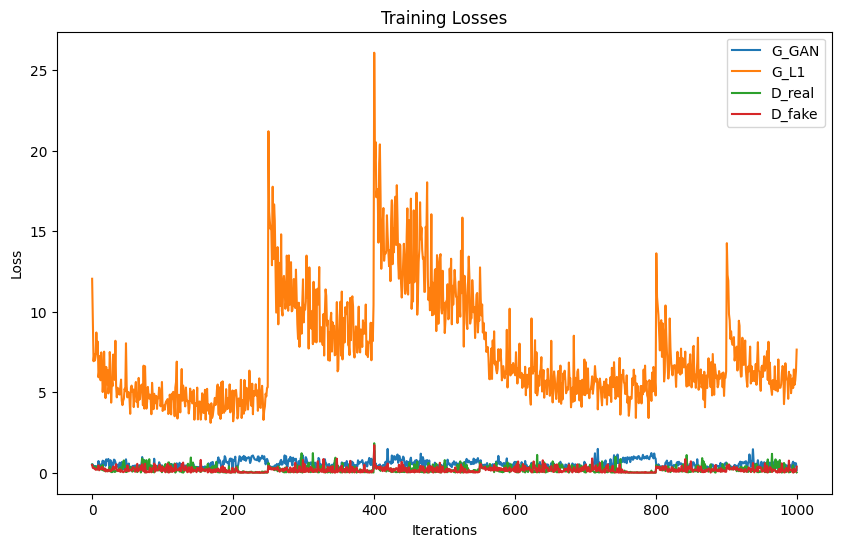

In [34]:
log_path = './checkpoints/cats_pix2pix/loss_log.txt'

iters = []
G_GAN = []
G_L1 = []
D_real = []
D_fake = []

with open(log_path, 'r') as f:
    for line in f:
        if 'G_GAN' in line:
            iter_num = int(re.search(r'epoch: (\d+), iters: (\d+)', line).group(2))
            iters.append(iter_num)

            G_GAN.append(float(re.search(r'G_GAN: ([\d\.]+)', line).group(1)))
            G_L1.append(float(re.search(r'G_L1: ([\d\.]+)', line).group(1)))
            D_real.append(float(re.search(r'D_real: ([\d\.]+)', line).group(1)))
            D_fake.append(float(re.search(r'D_fake: ([\d\.]+)', line).group(1)))


plt.figure(figsize=(10,6))
plt.plot(G_GAN, label='G_GAN')
plt.plot(G_L1, label='G_L1')
plt.plot(D_real, label='D_real')
plt.plot(D_fake, label='D_fake')

plt.legend()
plt.title('Training Losses')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()

Visualizanco las pérdidas se ve un comportamiento más equilibrado entre el generador y el discriminador. A diferencia de experimentos anteriores donde el discriminador colapsaba, en este caso se observaron valores que varían en D_real y D_fake, indicando una competencia efectiva entre ambas redes.

Este equilibrio permitió un entrenamiento más estable, reflejado en pérdidas del generador (G_GAN) más consistentes.

## <font color=  #003366> **Test del modelo**</font>

In [35]:
!export PYTHONPATH=$PYTHONPATH:/content/Project2_GANs/src/models/apdrawing_gan && \
python src/models/apdrawing_gan/test.py \
--dataroot /content/Project2_GANs/dataset \
--name cats_pix2pix \
--model apdrawing_gan \
--netG unet_256 \
--dataset_mode aligned \
--which_direction AtoB \
--phase test \
--num_threads 2 \
--gpu_ids 0

----------------- Options ---------------
                    EYE_H: 40                            
                    EYE_W: 56                            
                  MOUTH_H: 40                            
                  MOUTH_W: 64                            
                   NOSE_H: 48                            
                   NOSE_W: 48                            
             aspect_ratio: 1.0                           
           auxiliary_root: auxiliary                     
               batch_size: 1                             
                   bg_dir: dataset/mask/ALL              
          checkpoints_dir: ./checkpoints                 
                  comb_op: 1                             
                 dataroot: /content/Project2_GANs/dataset	[default: None]
             dataset_mode: aligned                       
              display_env: main                          
               display_id: 1                             
             d

Para la etapa de prueba se usó el modelo ya entrenado para generar sketches a partir de nuevas imágenes que no había visto antes.

En esta parte se carga el generador y se le pasan las imágenes del conjunto de test para ver cómo responde.

El modelo toma cada imagen de entrada y produce su versión en sketch, lo que permite evaluar si realmente aprendió la transformación o solo memorizó los datos de entrenamiento.

Estos resultados se guardan y se pueden comparar visualmente con los sketches reales, lo que ayuda a ver qué tan bien está funcionando el modelo en la práctica.

## <font color=  #003366> **Visualización**</font>

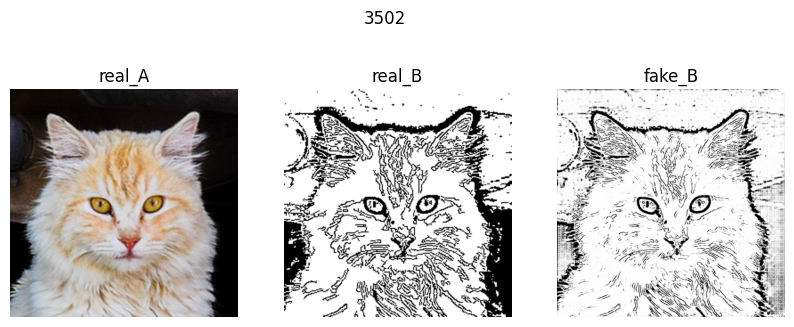

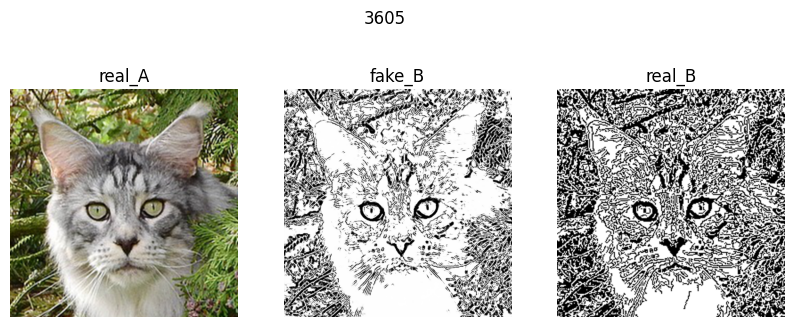

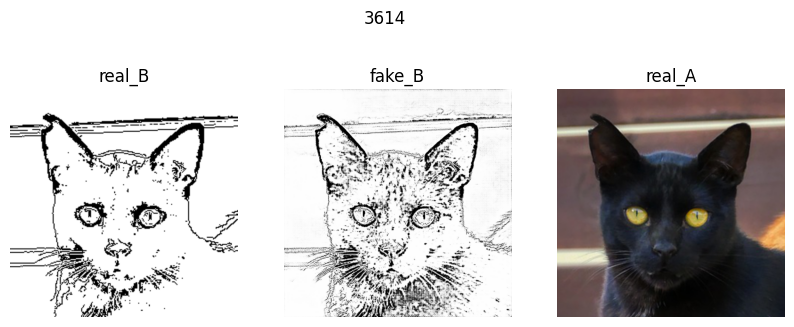

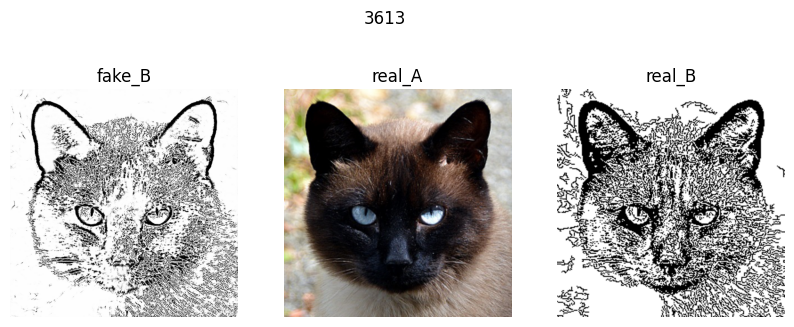

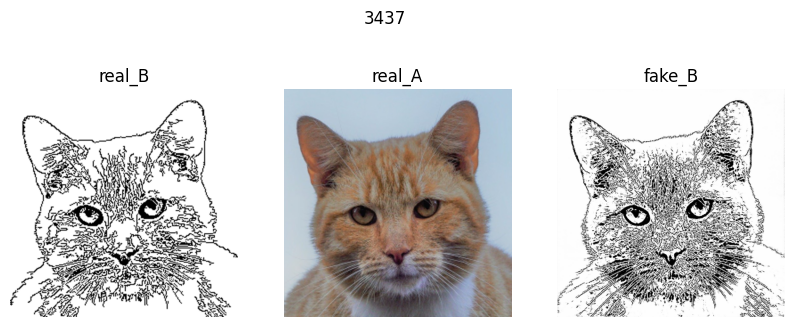

In [36]:
folder = "results/cats_pix2pix/test_latest/images"

files = os.listdir(folder)

data = {}

for f in files:
    base = f.split('_')[0]
    if base not in data:
        data[base] = {}

    if "real_A" in f:
        data[base]["real_A"] = f
    elif "real_B" in f:
        data[base]["real_B"] = f
    elif "fake_B" in f:
        data[base]["fake_B"] = f

count = 0

for key in data:
    if count >= 5:
        break

    if len(data[key]) == 3:
        fig, axs = plt.subplots(1, 3, figsize=(10,4))

        for i, (label, fname) in enumerate(data[key].items()):
            img = Image.open(os.path.join(folder, fname))
            axs[i].imshow(img)
            axs[i].set_title(label)
            axs[i].axis("off")

        plt.suptitle(key)
        plt.show()

        count += 1

Con esta gráfica podemos ver la comparación de la imagen real del gato, el skectch real y el sketch fake generado

## <font color=  #003366> **Guardar Generador**</font>

In [40]:
checkpoint = torch.load("checkpoints/cats_pix2pix/latest_net_gen.pt")
netG_state_dict = checkpoint["G"]
torch.save(netG_state_dict, "generator.pth")

## <font color=  #003366> **Métricas**</font>

In [37]:
folder = "results/cats_pix2pix/test_latest/images"

ssim_scores = []
psnr_scores = []

for file in os.listdir(folder):
    if "fake_B" in file:
        base = file.replace("fake_B.png", "")

        fake_path = os.path.join(folder, file)
        real_path = os.path.join(folder, base + "real_B.png")

        if os.path.exists(real_path):
            fake = cv2.imread(fake_path)
            real = cv2.imread(real_path)

            fake_gray = cv2.cvtColor(fake, cv2.COLOR_BGR2GRAY)
            real_gray = cv2.cvtColor(real, cv2.COLOR_BGR2GRAY)

            s = ssim(real_gray, fake_gray)
            p = psnr(real_gray, fake_gray)

            ssim_scores.append(s)
            psnr_scores.append(p)

print("SSIM promedio:", sum(ssim_scores)/len(ssim_scores))
print("PSNR promedio:", sum(psnr_scores)/len(psnr_scores))

SSIM promedio: 0.4795851188821153
PSNR promedio: 9.810383522591541


Para evaluar el desempeño del modelo se usaron dos métricas: SSIM y PSNR.

El SSIM (Structural Similarity Index) mide qué tan parecidas son dos imágenes en cuanto a la estructura, es decir, si conservan formas, bordes y detalles importantes, su valor va de 0 a 1, donde 1 significa que son prácticamente iguales. En este caso se obtuvo un SSIM promedio de 0.47, lo que indica que el modelo logra capturar la estructura de los sketches, aunque todavía hay diferencias visibles.

Por otro lado, el PSNR (Peak Signal-to-Noise Ratio) mide la calidad de la imagen comparando el nivel de error entre la imagen generada y la real, valores más altos indican mejor calidad. Se obtuvo un PSNR de 9.81, lo cual es relativamente bajo, lo que sugiere que aunque los resultados son reconocibles, todavía hay diferencias en los detalles.

### <font color=  #003366> **FID**</font>

In [38]:
results_dir = "results/cats_pix2pix/test_latest/images"
test_dir = "dataset/test"

fake_dir = "fid/fake"
real_dir = "fid/real"

os.makedirs(fake_dir, exist_ok=True)
os.makedirs(real_dir, exist_ok=True)

for f in os.listdir(results_dir):
    if "fake_B" in f:
        shutil.copy(os.path.join(results_dir, f), fake_dir)

for f in os.listdir(test_dir):
    path = os.path.join(test_dir, f)
    img = cv2.imread(path)

    h, w, _ = img.shape
    B = img[:, w//2:]

    cv2.imwrite(os.path.join(real_dir, f), B)

In [39]:
!python -m pytorch_fid fid/real fid/fake

100% 2/2 [00:00<00:00,  2.14it/s]
100% 2/2 [00:01<00:00,  1.95it/s]
FID:  106.3191402125644


In [41]:
sys.path.append('/content/Project2_GANs/src/models/apdrawing_gan')

from models.networks import define_G

device = "cuda" if torch.cuda.is_available() else "cpu"

netG = define_G(
    input_nc=3,
    output_nc=1,
    ngf=64,
    netG='unet_256',
    norm='batch',
    use_dropout=False,
    init_type='normal',
    init_gain=0.02,
    gpu_ids=[]
)

netG.load_state_dict(torch.load("generator.pth", map_location=device))

netG.to(device)
netG.eval()

print("Generador cargado correctamente")

initialize network with normal
Generador cargado correctamente


In [42]:
torch.save(netG.state_dict(), "generator.pth")

In [43]:
def add_noise(img, level):
    noise = np.random.normal(0, level, img.shape)
    noisy = img + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

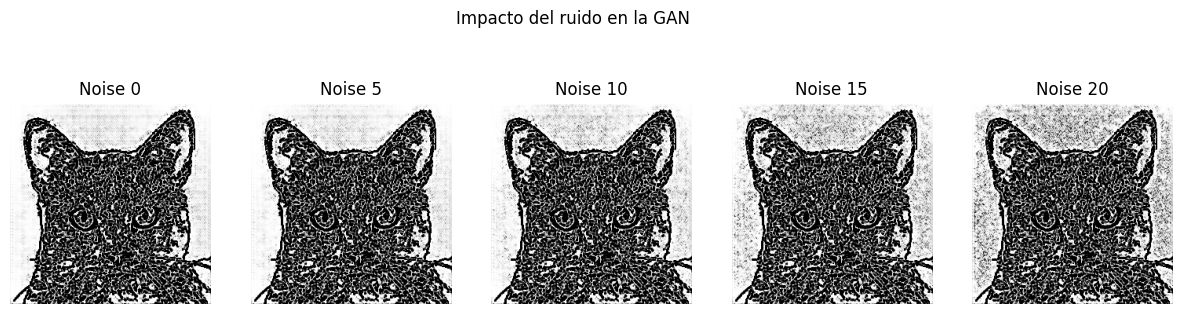

In [51]:
img_path = "fid/real/3412.png"
img = cv2.imread(img_path)

disturbance_levels = [0, 5, 10, 15, 20]

plt.figure(figsize=(15,4))

for i, level in enumerate(disturbance_levels):

    noise = np.random.normal(0, level, img.shape)
    noisy = img + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)

    img_in = cv2.resize(noisy, (256, 256))
    img_in = img_in.astype(np.float32) / 255.0
    img_in = (img_in - 0.5) / 0.5
    img_in = np.transpose(img_in, (2, 0, 1))
    img_in = torch.tensor(img_in).unsqueeze(0).to(device)

    with torch.no_grad():
        fake = netG(img_in)

    fake = fake.squeeze().cpu().numpy()
    fake = (fake + 1) / 2 * 255
    fake = np.clip(fake, 0, 255).astype(np.uint8)

    plt.subplot(1, len(disturbance_levels), i+1)
    plt.imshow(fake, cmap='gray')
    plt.title(f"Noise {level}")
    plt.axis("off")

plt.suptitle("Impacto del ruido en la GAN")
plt.show()

In [52]:
disturbance_levels = [5, 10, 15, 20]
fid_scores = []

In [53]:
real_folder = "fid/real"
fake_folder = "fid/fake_temp"

os.makedirs(fake_folder, exist_ok=True)

image_paths = os.listdir(real_folder)

for level in disturbance_levels:
    print(f"\nNivel de ruido: {level}")

    # limpiar carpeta fake
    shutil.rmtree(fake_folder)
    os.makedirs(fake_folder)

    for img_name in image_paths:
        path = os.path.join(real_folder, img_name)
        img = cv2.imread(path)

        noisy = add_noise(img, level)

        img_in = cv2.resize(noisy, (256, 256))
        img_in = img_in.astype(np.float32) / 255.0
        img_in = (img_in - 0.5) / 0.5
        img_in = np.transpose(img_in, (2, 0, 1))
        img_in = torch.tensor(img_in).unsqueeze(0).to(device)

        with torch.no_grad():
            fake = netG(img_in)

        fake = fake.squeeze().cpu().numpy()
        fake = (fake + 1) / 2 * 255
        fake = np.clip(fake, 0, 255).astype(np.uint8)

        cv2.imwrite(os.path.join(fake_folder, img_name), fake)

    fid = fid_score.calculate_fid_given_paths(
        [real_folder, fake_folder],
        batch_size=16,
        device=device,
        dims=2048
    )

    fid_scores.append(fid)
    print(f"FID: {fid}")


Nivel de ruido: 5


100%|██████████| 7/7 [00:00<00:00,  9.89it/s]


FID: 191.86837849001245

Nivel de ruido: 10


100%|██████████| 7/7 [00:00<00:00, 12.18it/s]


FID: 197.21057356351696

Nivel de ruido: 15


100%|██████████| 7/7 [00:00<00:00, 10.08it/s]


FID: 198.202339865451

Nivel de ruido: 20


100%|██████████| 7/7 [00:00<00:00, 12.10it/s]


FID: 198.57053892585282


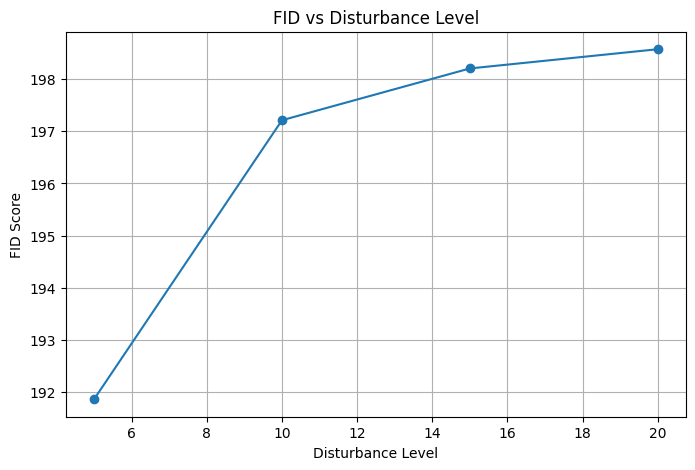

In [54]:
plt.figure(figsize=(8,5))
plt.plot(disturbance_levels, fid_scores, marker='o')
plt.xlabel("Disturbance Level")
plt.ylabel("FID Score")
plt.title("FID vs Disturbance Level")
plt.grid()

plt.show()

## <font color=  #003366> **FID Custom: SMD**</font>

Además del FID se implementó nuestro FID custom el cual se calcula la diferencia entre las distribuciones mediante la distancia entre medias y el determinante de la diferencia entre matrices de covarianza

In [55]:
real_dir = "fid/real"
fake_dir = "fid/fake"

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

def load_images(folder, max_imgs=50):
    imgs = []
    files = sorted(os.listdir(folder))[:max_imgs]

    for fname in files:
        path = os.path.join(folder, fname)
        img = Image.open(path).convert("RGB")
        img = transform(img)
        imgs.append(img)

    return torch.stack(imgs)

real_imgs = load_images(real_dir)
fake_imgs = load_images(fake_dir)

In [56]:
extractor = resnet18(weights="IMAGENET1K_V1")
extractor.fc = nn.Identity()
extractor.eval()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [57]:
@torch.no_grad()
def get_feats(model, imgs):
    feats = model(imgs)
    return feats.cpu().numpy()

real_feat = get_feats(extractor, real_imgs)
fake_feat = get_feats(extractor, fake_imgs)

In [58]:
def fid_det(mu1, sigma1, mu2, sigma2):
    C = sigma1 - sigma2
    det_val = np.linalg.det(C)
    det_val = abs(det_val)
    mean_term = np.sum((mu1 - mu2)**2)
    return mean_term + det_val

In [59]:
mu_r, sigma_r = real_feat.mean(0), np.cov(real_feat, rowvar=False)
mu_f, sigma_f = fake_feat.mean(0), np.cov(fake_feat, rowvar=False)

fid_custom = fid_det(mu_r, sigma_r, mu_f, sigma_f)

print("FID custom:", fid_custom)

FID custom: 39.33012771606445
